In [1]:
import pickle as pk
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

import shap

import sys, os
sys.path.append(os.path.abspath(os.path.join(os.path.dirname("./"), os.pardir)))
from customFunctions.utils import binary_auROC, feature_name_conversion

In [2]:
tapogee_features = pd.read_csv("../tAPOGEE/checkpoints/mithril_features.csv", sep="\t", index_col="Mithril_id")
tapogee_features

,PhastCons_100V,PhyloP_100V,MLC_score,ss_distorsion,ddG,ref_frequency,alt_frequency,coverage,entropy,conservation_blocks,PWM_score,Human_MSA_position,bulge,stem,hairpin,loop,unpaired_frequency,closest_modification,closest_modification_2D,OEUF_score
Mithril_id,,,,,,,,,,,,,,,,,,,,
MITHRIL.1728,1.000,3.724,0.117871,0.028169,3.8,0.832225,0.143385,1.0,0.769628,14.0,-0.802033,0,0,1,0,0,0.011603,8,8.0,0.470
MITHRIL.1729,1.000,3.724,0.117871,0.028169,3.7,0.832225,0.004435,1.0,0.769628,14.0,-5.816984,0,0,1,0,0,0.011603,8,8.0,0.470
MITHRIL.1730,1.000,3.724,0.117871,0.028169,3.7,0.832225,0.019956,1.0,0.769628,14.0,-3.647059,0,0,1,0,0,0.011603,8,8.0,0.470
MITHRIL.1731,0.989,1.697,0.128976,0.028169,4.3,0.509978,0.005174,1.0,1.096296,10.0,-5.594591,1,0,1,0,0,0.014503,7,7.0,0.358
MITHRIL.1732,0.989,1.697,0.128976,0.028169,4.3,0.509978,0.477458,1.0,1.096296,10.0,0.933444,1,0,1,0,0,0.014503,7,7.0,0.358
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MITHRIL.48239,1.000,3.604,0.738729,0.000000,0.7,0.956554,0.023564,1.0,0.316291,14.0,-3.407268,1,0,1,0,0,0.009386,7,5.0,0.358
MITHRIL.48240,1.000,3.604,0.738729,0.029412,4.7,0.956554,0.004418,1.0,0.316291,14.0,-5.822305,1,0,1,0,0,0.009386,7,5.0,0.358
MITHRIL.48241,1.000,5.938,0.734021,0.000000,1.9,0.981591,0.012518,1.0,0.154686,14.0,-4.319805,0,0,1,0,0,0.003610,8,6.0,0.470


In [3]:
tapogee_embedding = pd.read_csv("../tAPOGEE/data/Mithril_msm_embedding.csv", index_col=0)
tapogee_embedding.index.name = "Mithril_id"
tapogee_embedding.columns = "channel_"+tapogee_embedding.columns.astype(str)
tapogee_embedding

,channel_0,channel_1,channel_2,channel_3,channel_4,channel_5,channel_6,channel_7,channel_8,channel_9,...,channel_758,channel_759,channel_760,channel_761,channel_762,channel_763,channel_764,channel_765,channel_766,channel_767
Mithril_id,,,,,,,,,,,,,,,,,,,,,
MITHRIL.1728,-0.046571,-0.464829,-1.071173,0.706031,0.254538,-0.839300,-0.785148,-0.686940,-0.066750,-0.083101,...,0.703984,-0.094465,0.001146,-0.474778,0.054920,0.746596,-0.846664,0.056164,0.580686,-0.568011
MITHRIL.1729,-0.094558,-0.843313,-0.774938,0.836958,-0.283595,-0.961378,-0.578084,-0.701949,0.039039,-0.158005,...,0.391420,-0.352180,0.091886,-0.714017,0.015839,0.481953,-0.791229,0.398780,0.376998,0.029397
MITHRIL.1730,0.050315,-0.794720,-0.958813,0.551639,-0.071321,-0.767290,-0.558026,-0.843187,0.249865,-0.380568,...,0.306507,-0.153325,0.306693,-0.223419,-0.042577,0.929070,-0.781954,0.641456,0.126171,0.083980
MITHRIL.1731,-0.271729,-0.401465,-0.722368,0.715860,-0.171587,-0.678559,-0.540892,-0.339579,-0.256668,-0.268223,...,0.985569,0.165077,-0.349262,-0.658368,-0.430892,-0.193119,-0.840392,-0.930292,0.894584,-0.970570
MITHRIL.1732,-0.189935,-0.290123,-0.115013,0.859563,-0.127386,-0.715655,-0.411798,-0.926073,-0.151554,-0.170612,...,1.006938,-0.278918,-0.724813,-0.523815,-0.416955,0.000319,-1.031683,-0.880209,1.119973,-0.960705
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MITHRIL.48239,0.085203,0.720789,0.258117,-0.241561,0.276256,0.001175,0.117050,-0.357717,0.238088,0.165467,...,-0.069218,0.467677,-0.082058,0.037380,0.941805,-0.044995,-0.369644,0.526498,-0.601754,-0.447180
MITHRIL.48240,-0.516000,0.442102,0.331330,0.229251,-0.081880,-0.531516,0.226194,-0.564276,0.209845,-0.133919,...,-0.124533,0.285401,-0.201929,-0.403190,0.809152,0.175132,-0.162785,0.336191,-0.763395,-0.056434
MITHRIL.48241,0.318094,0.357954,-0.837745,-0.545639,-0.157910,0.394076,-1.226594,-0.005673,0.406269,-0.306028,...,-0.098943,0.436399,0.025024,1.110456,-0.265077,0.567142,-0.822745,-0.657988,-0.763098,-0.291456


In [4]:
X_tapogee = tapogee_features.join(tapogee_embedding)
X_tapogee.shape

(4521, 788)

In [5]:
tapogee = pk.load(open("../tAPOGEE/checkpoints/candidate_models/model_svc.pk", "rb"))
tapogee

GridSearchCV(cv=StratifiedKFold(n_splits=10, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('input_selection',
                                        ColumnTransformerDF(transformers=[('feature_selection',
                                                                           SelectFromModelDF(estimator=DecisionTreeClassifier(class_weight='balanced',
                                                                                                                              random_state=777),
                                                                                             threshold=0.01),
                                                                           Index(['PhastCons_100V', 'PhyloP_100V', 'MLC_score', 'ss_distorsion', '...
                                                                       scoring_function=<function roc_auc_score at 0x7efb6112be20>))]),
             n_jobs=1,
             param_grid={'channels_correlation_filter__corr_threshold': [0.2,
                                                                         0.25,
                                                                         0.3,
                                                                         0.4],
                         'channels_pca__n_components': [1, 2, 3, 5],
                         'input_selection__channel_selection__alpha': [0.01,
                                                                       0.05,
                                                                       0.1],
                         'input_selection__feature_selection__threshold': [0.01,
                                                                           0.02,
                                                                           0.03,
                                                                           0.04,
                                                                           0.05]},
             scoring=<function binary_auROC at 0x7efb57688b80>, verbose=2)

In [6]:
X_tapogee_transformed = tapogee.best_estimator_[:-1].transform(X_tapogee)
X_tapogee_transformed.index = X_tapogee.index
X_tapogee_transformed

,PhastCons_100V,PhyloP_100V,MLC_score,ss_distorsion,ddG,ref_frequency,alt_frequency,coverage,entropy,conservation_blocks,PWM_score,Human_MSA_position,unpaired_frequency,closest_modification,OEUF_score,PC_1,PC_2,PC_3,PC_4,PC_5
Mithril_id,,,,,,,,,,,,,,,,,,,,
MITHRIL.1728,1.176727,0.715253,-1.452850,1.545045,1.480352,0.954134,-0.299044,0.342769,-0.680620,1.598726,0.214831,-1.767824,-1.060829,0.041083,-0.450042,8.424408,0.856009,2.124207,1.073375,-2.424781
MITHRIL.1729,1.176727,0.715253,-1.452850,1.545045,1.430802,0.954134,-0.934654,0.342769,-0.680620,1.598726,-0.516145,-1.767824,-1.060829,0.041083,-0.450042,6.084116,0.545429,3.145983,0.805294,-2.821490
MITHRIL.1730,1.176727,0.715253,-1.452850,1.545045,1.430802,0.954134,-0.863655,0.342769,-0.680620,1.598726,-0.199858,-1.767824,-1.060829,0.041083,-0.450042,9.303537,-0.883934,1.786964,0.423214,-2.733128
MITHRIL.1731,1.153573,0.226994,-1.400037,1.545045,1.728104,-0.121783,-0.931273,0.342769,0.014163,0.746405,-0.483729,-1.723501,-1.054587,-0.094018,-0.728020,0.439282,3.921170,-1.328000,0.343577,-0.465627
MITHRIL.1732,1.153573,0.226994,-1.400037,1.545045,1.728104,-0.121783,1.229124,0.342769,0.014163,0.746405,0.467793,-1.723501,-1.054587,-0.094018,-0.728020,-2.713398,3.725281,-0.327298,-1.194881,-0.959551
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MITHRIL.48239,1.176727,0.686348,1.499799,-0.561018,-0.055708,1.369244,-0.847149,0.342769,-1.644813,1.598726,-0.164907,-1.723501,-1.065598,-0.094018,-0.728020,-2.575146,-3.879147,1.561551,-1.175544,-0.145825
MITHRIL.48240,1.176727,0.686348,1.499799,1.637960,1.926305,1.369244,-0.934729,0.342769,-1.644813,1.598726,-0.516921,-1.723501,-1.065598,-0.094018,-0.728020,-2.541791,-2.499284,2.950000,-1.056045,-2.065907
MITHRIL.48241,1.176727,1.248556,1.477411,-0.561018,0.538896,1.452837,-0.897676,0.342769,-1.988527,1.598726,-0.297917,-1.767824,-1.078029,0.041083,-0.450042,4.741607,-0.190472,-0.948027,-1.550220,1.576086


In [ ]:
shap_values = pk.load(open("../tAPOGEE/checkpoints/shap_values.pk", "rb"))
shap_values

.values =
array([[ 0.02603027,  0.01027484, -0.07136036, ...,  0.01038669,
        -0.01108692,  0.00098236],
       [ 0.0283104 ,  0.01067308, -0.07853886, ...,  0.01984199,
        -0.00993502, -0.00142979],
       [ 0.02430152,  0.01022929, -0.0718941 , ...,  0.00960183,
        -0.00456462, -0.00412577],
       ...,
       [ 0.03507034,  0.02230946,  0.05135978, ..., -0.00429501,
         0.03362231,  0.02032631],
       [ 0.0341897 ,  0.02186881,  0.0585517 , ..., -0.00933509,
        -0.02686218,  0.01212894],
       [ 0.03248965,  0.02055751,  0.05189003, ..., -0.00529243,
         0.01722437,  0.00664999]])

.base_values =
array([0.53454302, 0.53454302, 0.53454302, ..., 0.53454302, 0.53454302,
       0.53454302])

.data =
array([[ 1.17672734,  0.71525313, -1.45285028, ...,  2.12420729,
         1.07337485, -2.42478083],
       [ 1.17672734,  0.71525313, -1.45285028, ...,  3.14598257,
         0.80529375, -2.82149045],
       [ 1.17672734,  0.71525313, -1.45285028, ...,  1.78696

In [8]:
shap_values_df = pd.DataFrame(
    shap_values.values, index=X_tapogee_transformed.index,
    columns=X_tapogee_transformed.columns
)
shap_values_df["RNA_MSM"] = shap_values_df.loc[:, shap_values_df.columns.str.match("PC_")].sum(axis=1).rename("RNA_MSM")
shap_values_df = shap_values_df.loc[:, ~shap_values_df.columns.str.match("PC_")]
shap_values_df

,PhastCons_100V,PhyloP_100V,MLC_score,ss_distorsion,ddG,ref_frequency,alt_frequency,coverage,entropy,conservation_blocks,PWM_score,Human_MSA_position,unpaired_frequency,closest_modification,OEUF_score,RNA_MSM
Mithril_id,,,,,,,,,,,,,,,,
MITHRIL.1728,0.026030,0.010275,-0.071360,0.018107,0.032736,0.006480,0.003747,0.001171,0.008029,0.047008,0.011210,0.000189,-0.003434,0.000733,0.003400,0.151780
MITHRIL.1729,0.028310,0.010673,-0.078539,0.017598,0.032488,0.006986,-0.003353,0.000688,0.008943,0.051627,0.005540,0.001089,-0.005143,0.000417,0.003426,0.088273
MITHRIL.1730,0.024302,0.010229,-0.071894,0.015742,0.028347,0.005903,-0.002523,0.000923,0.007771,0.045526,0.008131,-0.000447,-0.004289,0.000488,0.002933,0.161785
MITHRIL.1731,0.032253,-0.000457,-0.102766,0.019652,0.044360,-0.005713,-0.005026,-0.001756,-0.004246,0.026917,0.003704,0.000110,-0.000756,0.000291,0.010158,-0.030302
MITHRIL.1732,0.030945,0.000692,-0.100109,0.026612,0.050660,-0.004567,0.020421,-0.002483,-0.002200,0.029037,0.009208,-0.000497,0.001799,0.000644,0.009814,0.027806
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MITHRIL.48239,0.029336,0.010806,0.061857,-0.011713,-0.012163,0.010465,-0.003394,-0.003887,0.021826,0.056782,0.005054,0.002781,-0.007333,-0.000114,0.006234,-0.035372
MITHRIL.48240,0.025405,0.010347,0.052856,0.015333,0.037720,0.008405,-0.005439,-0.003132,0.015813,0.052290,0.004959,-0.000173,-0.004311,0.000355,0.005936,0.022374
MITHRIL.48241,0.035070,0.022309,0.051360,-0.006276,0.006167,0.013585,-0.000385,-0.000247,0.030270,0.045473,0.007555,0.001882,-0.006789,0.000724,0.003819,0.102346


In [9]:
n_rows = int(len(X_tapogee_transformed.columns)**.5) +1
n_cols = n_rows - 1
n_cols, n_rows

(4, 5)

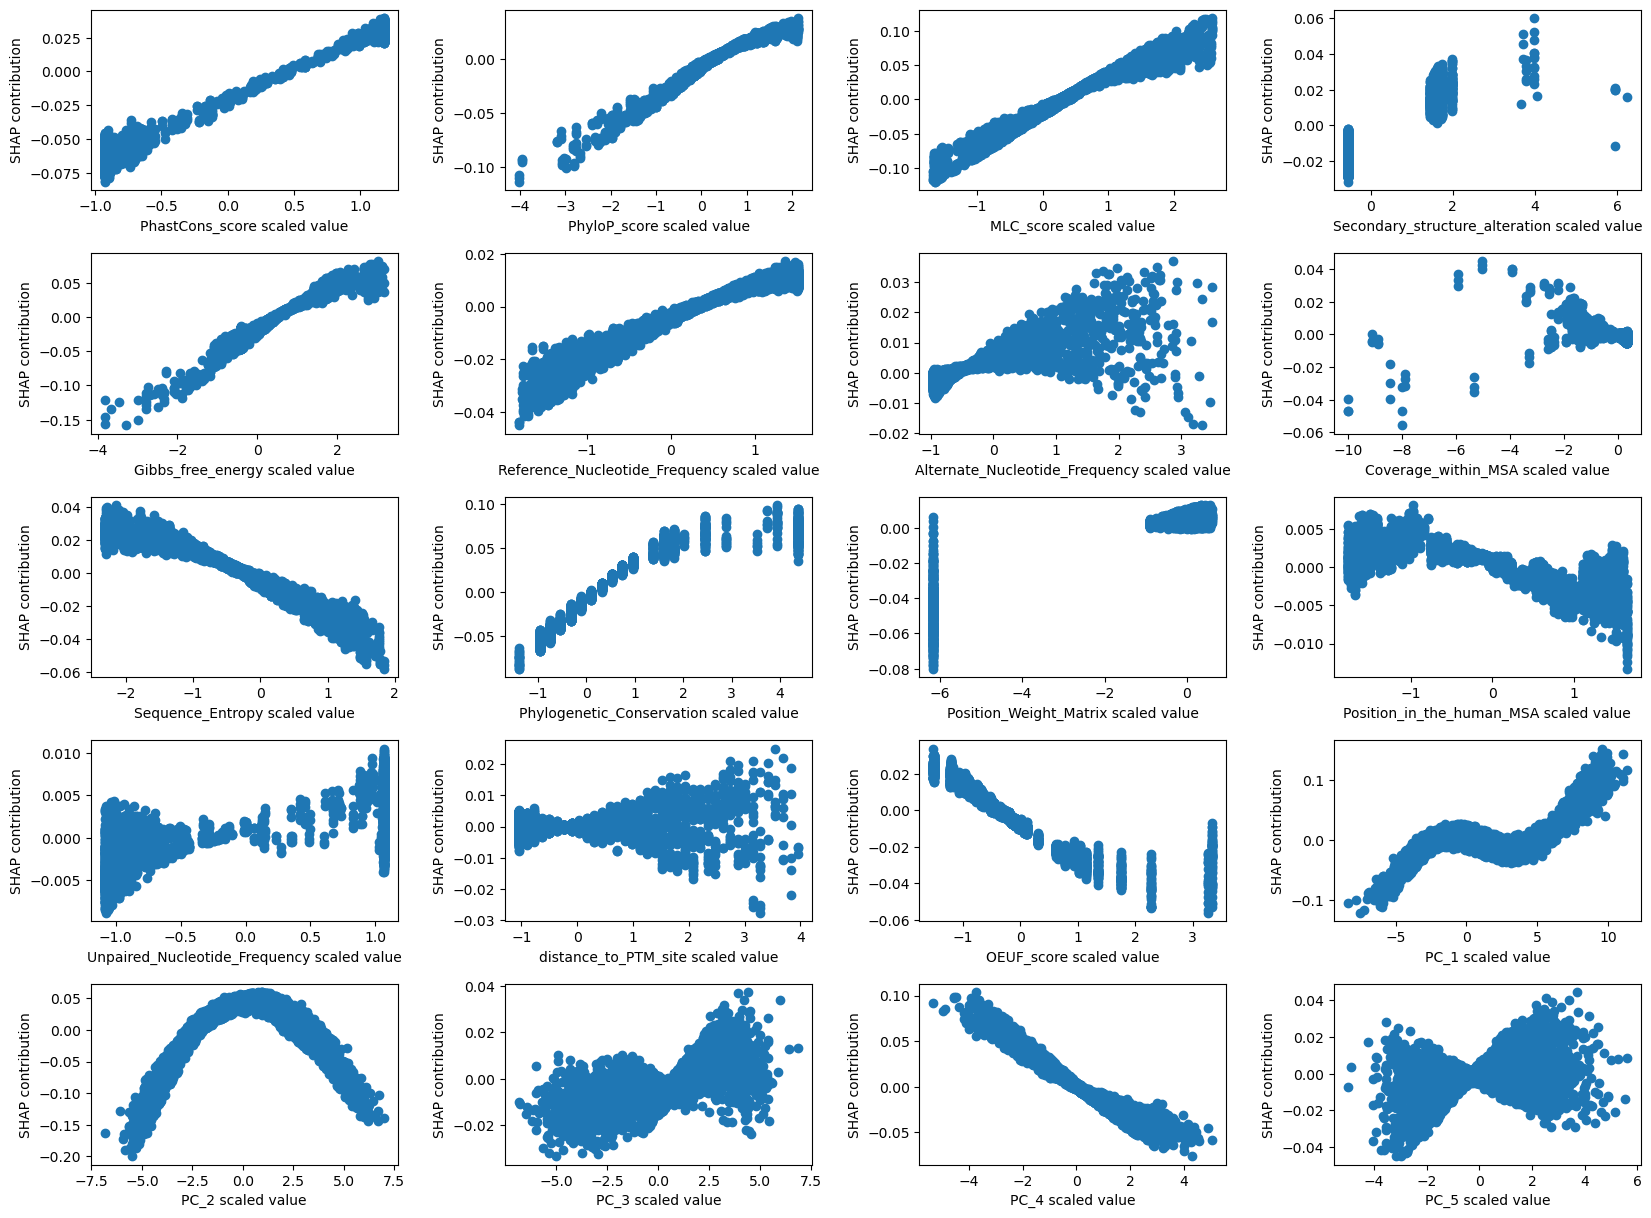

In [10]:
plt.figure(figsize=(20, 15))
plt.subplots_adjust(hspace=.35, wspace=.35)
for i, feature in enumerate(X_tapogee_transformed.columns):
    plt.subplot(n_rows, n_cols, i+1)
    idx = np.argsort(shap_values[:,i].data)
    plt.scatter(shap_values[idx,i].data, shap_values[idx,i].values)
    plt.xlabel(f"{feature_name_conversion(feature)} scaled value")
    plt.ylabel("SHAP contribution")

plt.savefig("./svg/shap_contributions_tAPOGEE.svg")
plt.show()

In [11]:
# normalizing to have feature importances sum to 1
shap_importances = shap_values_df.abs().sum().rename("shap_importances")
shap_importances /= shap_importances.sum()
shap_importances

PhastCons_100V          0.130704
PhyloP_100V             0.053009
MLC_score               0.140234
ss_distorsion           0.052928
ddG                     0.104843
ref_frequency           0.033946
alt_frequency           0.013462
coverage                0.008021
entropy                 0.049785
conservation_blocks     0.112652
PWM_score               0.026890
Human_MSA_position      0.007237
unpaired_frequency      0.011202
closest_modification    0.007379
OEUF_score              0.039526
RNA_MSM                 0.208180
Name: shap_importances, dtype: float64

In [12]:
tapogee_training_importance = pd.Series(
    tapogee.best_estimator_[0]["feature_selection"].estimator_.feature_importances_,
    index=tapogee_features.columns
).rename("tree_training_importance")
tapogee_training_importance

PhastCons_100V             2.442173e-01
PhyloP_100V                7.166909e-02
MLC_score                  1.164619e-01
ss_distorsion              3.350041e-02
ddG                        9.309108e-02
ref_frequency              3.790409e-02
alt_frequency              3.273588e-02
coverage                   3.830918e-02
entropy                    1.741323e-02
conservation_blocks        8.895542e-02
PWM_score                  6.825934e-02
Human_MSA_position         2.912328e-02
bulge                      1.176328e-16
stem                       2.829654e-18
hairpin                    0.000000e+00
loop                       1.735419e-03
unpaired_frequency         4.523331e-02
closest_modification       3.105308e-02
closest_modification_2D    3.981768e-03
OEUF_score                 4.635630e-02
Name: tree_training_importance, dtype: float64

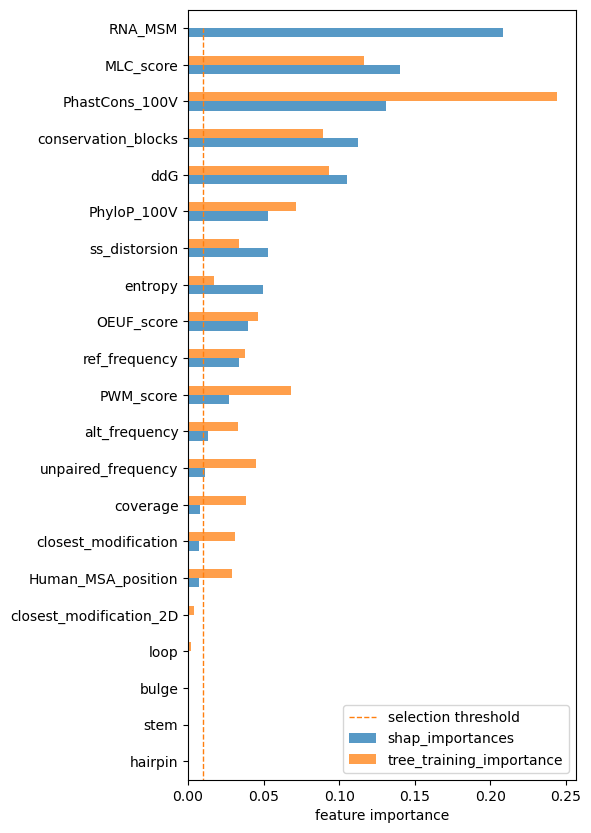

In [29]:
plt.figure(figsize=(5,10))
ax = plt.subplot(111)
shap_importances.to_frame().join(tapogee_training_importance, how="outer").fillna(0.).sort_values(["shap_importances", "tree_training_importance"], ascending=True).plot.barh(ax=ax, alpha=.75)
plt.vlines(
    tapogee.best_estimator_[0]["feature_selection"].threshold,
    -1, len(tapogee_features.columns),
    ls="--", color="C1", lw=1,
    label="selection threshold"
)
plt.legend(loc="lower right")
plt.xlabel("feature importance")
plt.show()

In [14]:
rapogee_features = pd.read_csv("../rAPOGEE/checkpoints/mithril_features.csv", sep="\t", index_col="Mithril_id")
rapogee_features

,PhastCons_100V,PhyloP_100V,MLC_score,closest_modification,closest_modification_2D,ref_frequency,alt_frequency,coverage,entropy,conservation_blocks,PWM_score,ddG,x_coord,y_coord,z_coord
Mithril_id,,,,,,,,,,,,,,,
MITHRIL.1941,0.016,-1.211,0.519343,428,68.0,0.063046,0.734159,0.414031,1.007675,5.0,1.554394,0.0,74.989870,3.792304,-17.815130
MITHRIL.1942,0.016,-1.211,0.519343,428,68.0,0.063046,0.027632,0.414031,1.007675,5.0,-3.177276,0.0,74.989870,3.792304,-17.815130
MITHRIL.1943,0.016,-1.211,0.519343,428,68.0,0.063046,0.175004,0.414031,1.007675,5.0,-0.514311,0.0,74.989870,3.792304,-17.815130
MITHRIL.1944,0.984,8.630,0.536906,427,67.0,0.943580,0.005642,0.431192,0.690667,5.0,-5.469367,0.0,78.754455,2.011318,-16.298545
MITHRIL.1945,0.984,8.630,0.536906,427,67.0,0.943580,0.020433,0.431192,0.690667,5.0,-3.612731,0.0,78.754455,2.011318,-16.298545
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MITHRIL.9683,0.000,-1.952,0.681815,160,63.0,0.331219,0.227366,0.414689,1.237161,4.0,-0.136909,0.0,-39.321650,77.760650,-31.156100
MITHRIL.9684,0.000,-1.952,0.681815,160,63.0,0.331219,0.035675,0.414689,1.237161,4.0,-2.808957,-0.2,-39.321650,77.760650,-31.156100
MITHRIL.9685,0.000,-0.833,0.709337,161,64.0,0.643931,0.186358,0.284371,0.908297,3.0,-0.423848,0.0,-31.769100,74.606700,-33.021850


In [15]:
rapogee_embedding = pd.read_csv("../rAPOGEE/data/Mithril_embedding_variants_256windows.csv", index_col=0, sep="\t")
rapogee_embedding.index.name = "Mithril_id"
rapogee_embedding.columns = "channel_"+rapogee_embedding.columns.astype(str)
rapogee_embedding

,channel_0,channel_1,channel_2,channel_3,channel_4,channel_5,channel_6,channel_7,channel_8,channel_9,...,channel_758,channel_759,channel_760,channel_761,channel_762,channel_763,channel_764,channel_765,channel_766,channel_767
Mithril_id,,,,,,,,,,,,,,,,,,,,,
MITHRIL.1941,0.303513,1.383160,0.638585,-0.056332,0.176263,-0.143039,-0.985142,-0.073643,0.336082,-0.599478,...,-0.664787,0.342638,-0.699671,0.348487,0.340148,-0.661547,-0.597864,-0.348987,0.034101,-0.789595
MITHRIL.1942,0.550209,1.220003,0.230237,-0.072172,0.307337,-0.080652,-1.192470,0.338680,0.417476,-0.599843,...,-0.795870,0.374328,-0.212471,0.258718,0.568081,-0.767436,-0.461378,0.112244,-0.375101,-0.613042
MITHRIL.1943,0.459543,1.446819,0.370377,-0.316391,0.367811,0.119868,-0.938122,0.148861,0.658042,-0.837851,...,-0.601526,0.258426,-0.295742,0.531571,0.098219,-0.288436,-0.316600,-0.029138,-0.262222,-0.427665
MITHRIL.1944,0.118863,1.211255,0.680541,0.772733,0.030618,-0.126848,-0.616585,0.319752,0.465699,-0.481459,...,-0.197357,0.359017,-0.049334,-0.141238,-0.017622,0.085889,-0.126867,0.402710,0.525452,0.224361
MITHRIL.1945,0.174472,1.160523,0.451300,0.105366,0.336155,-0.178989,-0.596600,0.255072,0.611938,-0.435275,...,-0.372028,0.596866,0.099172,0.075484,-0.035451,-0.114921,-0.501647,0.671988,0.081063,-0.250176
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MITHRIL.9683,0.718890,0.957562,0.375530,1.028451,0.426534,-0.871481,-0.440027,-0.612123,-0.065064,-0.365776,...,0.180092,0.376471,-0.410671,-0.552921,0.194272,-0.247190,-0.207616,-0.102479,0.734206,-0.471182
MITHRIL.9684,0.859912,0.645613,-0.226261,0.669992,0.278951,-0.784824,-0.595451,-0.105677,-0.029068,-0.408974,...,-0.045239,0.154268,0.257173,-0.739464,0.196565,-0.440911,-0.431372,0.007138,0.411753,-0.449467
MITHRIL.9685,0.567578,0.794154,0.440818,0.410750,0.398513,-0.607294,-0.894730,-0.127402,0.098248,-0.188302,...,0.814643,-0.055371,0.330179,-0.671677,0.158416,-0.441889,-0.294790,-0.144047,0.570522,-0.642164


In [16]:
X_rapogee = rapogee_features.join(rapogee_embedding)
X_rapogee.shape

(7536, 783)

In [17]:
rapogee = pk.load(open("../rAPOGEE/checkpoints/candidate_models/model_rf.pk", "rb"))
rapogee

Pipeline(steps=[('input_selection',
                 ColumnTransformerDF(transformers=[('feature_selection',
                                                    SelectFromModelDF(estimator=DecisionTreeClassifier(class_weight='balanced',
                                                                                                       random_state=777),
                                                                      threshold=0.01),
                                                    Index(['PhastCons_100V', 'PhyloP_100V', 'MLC_score', 'closest_modification',
       'closest_modification_2D', 'ref_frequency', 'alt_frequency', 'coverage',
       'entropy'...
                 GridSearchOOB_BinaryClassifier(estimator=BalancedRandomForestClassifier(bootstrap=True,
                                                                                         criterion='entropy',
                                                                                         max_depth=9,
                                                                                         max_features=0.1,
                                                                                         n_estimators=4096,
                                                                                         n_jobs=-1,
                                                                                         oob_score=True,
                                                                                         sampling_strategy={0: 22,
                                                                                                            1: 22}),
                                                n_jobs=16,
                                                param_grid=<sklearn.model_selection._search.ParameterGrid object at 0x7efb3d25fed0>,
                                                scoring_function=<function roc_auc_score at 0x7efb6112be20>,
                                                verbose=99))])

In [19]:
rapogee_training_importance = pd.Series(
    rapogee[0]["feature_selection"].estimator_.feature_importances_,
    index=rapogee_features.columns
).rename("tree_training_importance")
rapogee_training_importance

PhastCons_100V             2.795160e-05
PhyloP_100V                1.596278e-02
MLC_score                  3.554724e-01
closest_modification       2.064936e-01
closest_modification_2D    7.239849e-03
ref_frequency              8.133917e-02
alt_frequency              9.067124e-03
coverage                   3.220526e-02
entropy                    1.247283e-02
conservation_blocks        3.160028e-18
PWM_score                  1.855288e-03
ddG                        1.922791e-02
x_coord                    7.241726e-02
y_coord                    2.990598e-02
z_coord                    1.563126e-01
Name: tree_training_importance, dtype: float64

In [20]:
rf_importance = pd.Series(
    rapogee[-1].estimator.feature_importances_,
    index=rapogee[-1].estimator.feature_names_in_,
    name="rf_importance"
)
rf_importance["RNA_MSM"] = rf_importance[rf_importance.index.str.match("^PC_")].sum()
rf_importance = rf_importance[~rf_importance.index.str.match("^PC_")]
rf_importance

PhyloP_100V             0.065833
MLC_score               0.084719
closest_modification    0.087695
ref_frequency           0.070628
coverage                0.072363
entropy                 0.059384
ddG                     0.053639
x_coord                 0.073622
y_coord                 0.060845
z_coord                 0.059764
RNA_MSM                 0.311506
Name: rf_importance, dtype: float64

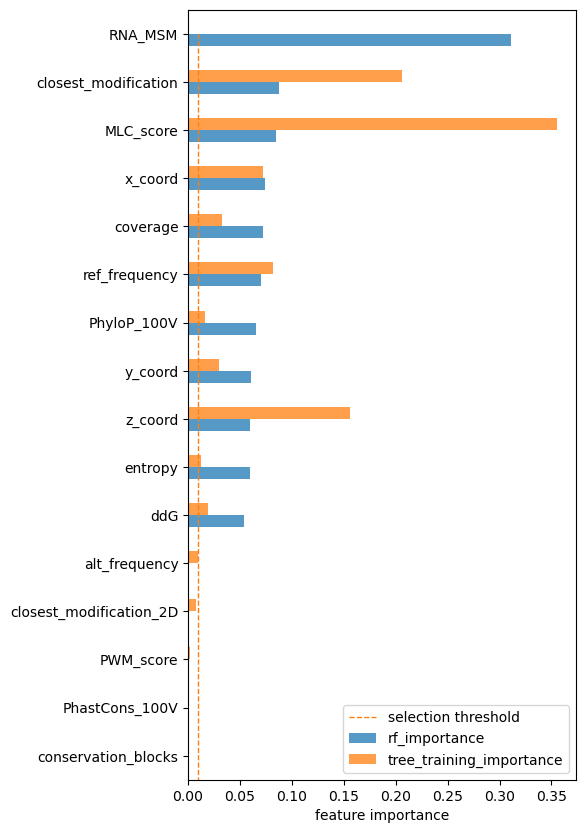

In [24]:
plt.figure(figsize=(5,10))
ax = plt.subplot(111)
rf_importance.to_frame().join(rapogee_training_importance, how="outer").fillna(0.).sort_values(["rf_importance", "tree_training_importance"], ascending=True).plot.barh(ax=ax, alpha=.75)
plt.vlines(
    rapogee[0]["feature_selection"].threshold,
    -1, len(rapogee_features.columns),
    ls="--", color="C1", lw=1,
    label="selection threshold"
)
plt.legend(loc="lower right")
plt.xlabel("feature importance")
plt.show()

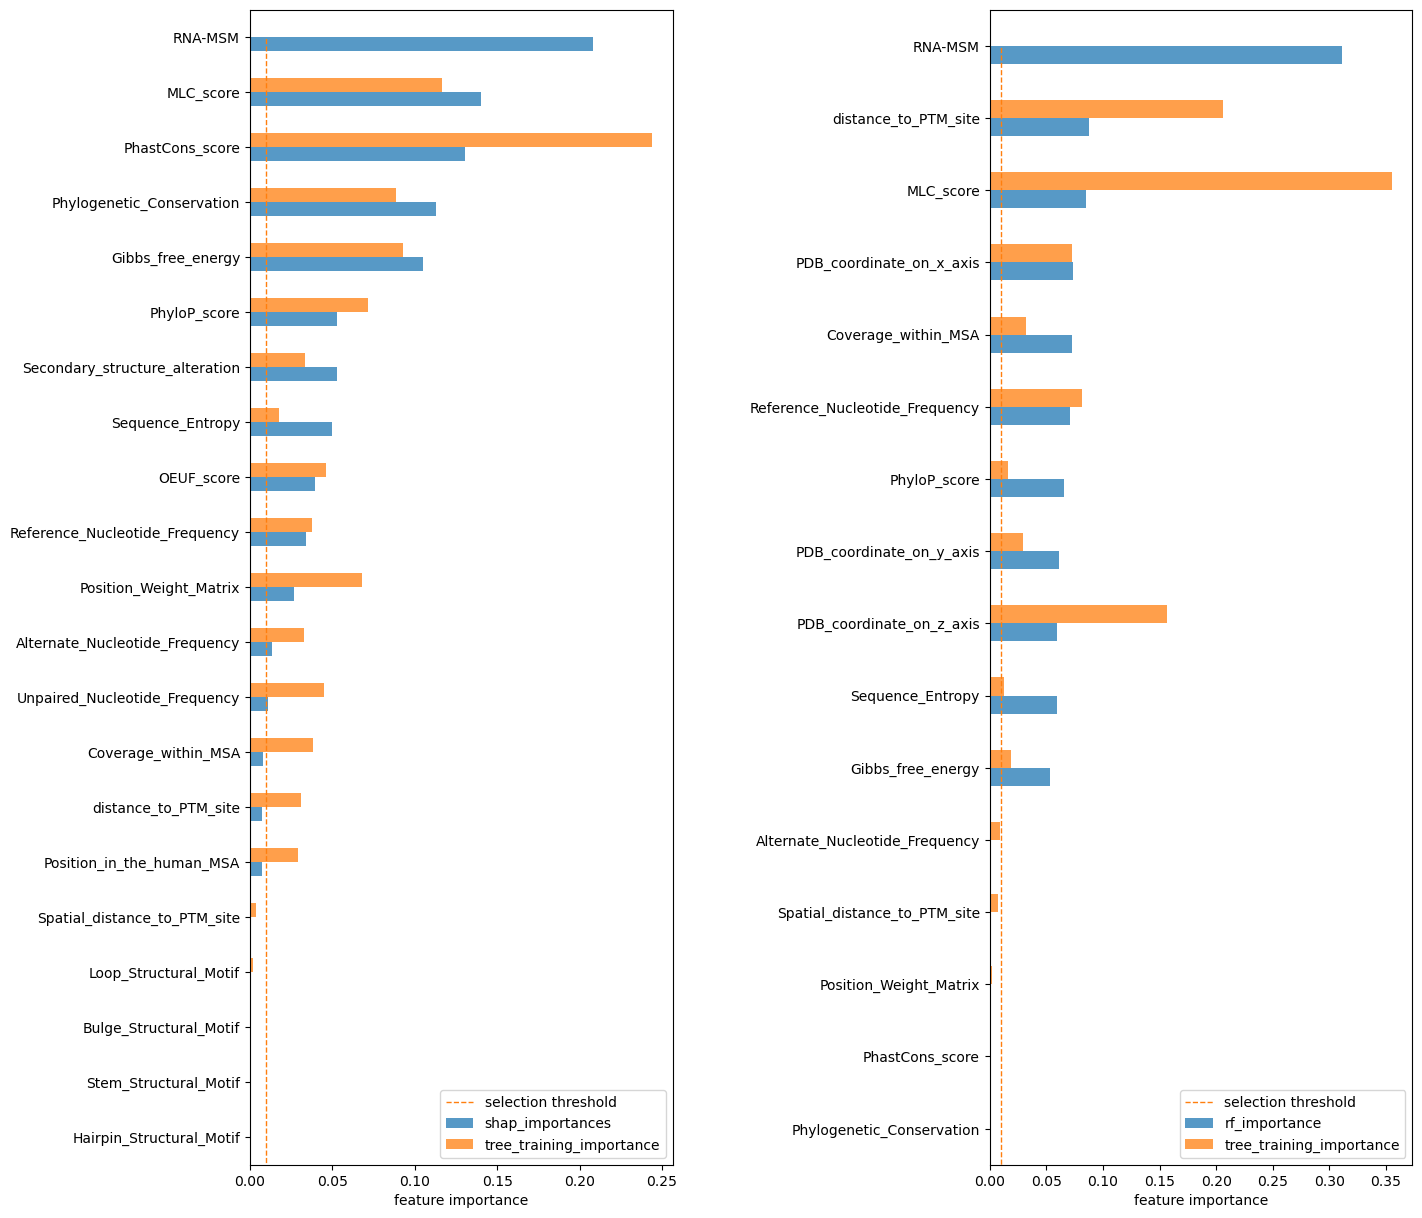

In [43]:
plt.figure(figsize=(15, 15))
plt.subplots_adjust(wspace=.75)

################# tAPOGEE #################
ax = plt.subplot(1,2,1)
shap_importances.to_frame().join(tapogee_training_importance, how="outer").fillna(0.).sort_values(["shap_importances", "tree_training_importance"], ascending=True).rename(feature_name_conversion).plot.barh(ax=ax, alpha=.75)
plt.vlines(
    tapogee.best_estimator_[0]["feature_selection"].threshold,
    -1, len(tapogee_features.columns),
    ls="--", color="C1", lw=1,
    label="selection threshold"
)
plt.legend(loc="lower right")
plt.xlabel("feature importance")



################# rAPOGEE #################
ax = plt.subplot(1,2,2)
rf_importance.to_frame().join(rapogee_training_importance, how="outer").fillna(0.).sort_values(["rf_importance", "tree_training_importance"], ascending=True).rename(feature_name_conversion).plot.barh(ax=ax, alpha=.75)
plt.vlines(
    rapogee[0]["feature_selection"].threshold,
    -1, len(rapogee_features.columns),
    ls="--", color="C1", lw=1,
    label="selection threshold"
)
plt.legend(loc="lower right")
plt.xlabel("feature importance")

plt.savefig("./svg/feature_importance.svg")
plt.show()
